# LightGBM Classificator Optimization

## 1. Setup and Data Loading

In [36]:
import os
import sys
import pandas as pd
import seaborn as sns

sys.path.append("..\src")

from src.models.mlflow_tracking import configure_mlflow, run_experiment

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ognjen.vujovic\AppData\Local\Temp\ipykernel_25368\585914988.py:6: SyntaxWarning: invalid escape sequence '\s'
  sys.path.append("..\src")


In [27]:
%matplotlib inline

In [4]:
TRAIN_PATH = "../data/processed/v1/feature_matrix_train.csv"
TEST_PATH = "../data/processed/v1/feature_matrix_test.csv"

df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)

print(f"Train shape: {df_train.shape}")
print(f"Test shape:  {df_test.shape}")

Train shape: (98589, 44)
Test shape:  (24709, 44)


In [5]:
TARGET = "experience_level_ord"

# Drop rows where target is missing
train_before = len(df_train)
test_before = len(df_test)

df_train = df_train.dropna(subset=[TARGET]).reset_index(drop=True)
df_test = df_test.dropna(subset=[TARGET]).reset_index(drop=True)

FEATURES = [col for col in df_train.columns if col != TARGET]

X_train = df_train[FEATURES]
y_train = df_train[TARGET].astype(int)

X_test = df_test[FEATURES]
y_test = df_test[TARGET].astype(int)


print(f"Train: {train_before} -> {len(df_train)} ({train_before - len(df_train)} dropped due to missing target)")
print(f"Test:  {test_before} -> {len(df_test)} ({test_before - len(df_test)} dropped due to missing target)")

Train: 98589 -> 79440 (19149 dropped due to missing target)
Test:  24709 -> 19948 (4761 dropped due to missing target)


## 2. Optuna hyperparameter optimization

In [ ]:
import optuna
from models.mlflow_tracking import configure_mlflow, run_experiment, compare_runs
from models.train_lightgbm import train_lgbm_classifier, get_feature_importance, CLASSIFIER_DEFAULT_PARAMS
from utils.evaluation import compute_metrics

configure_mlflow()


# ---- 1. Define the Optuna objective ----

def objective(trial):    
    params = {
        # core tree structure
        "num_leaves": trial.suggest_int("num_leaves", 16, 128),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),

        # learning rate
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),

        # stochastic components
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),

        # regularization
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "n_estimators": 5000,  # fixed large number with early stopping
    }

    # Train without MLflow -- just get the model and metrics
    model = train_lgbm_classifier(X_train, y_train, params=params)
    y_pred = model.predict(X_test)
    metrics = compute_metrics(y_test, y_pred)

    # Return the single metric Optuna should optimize
    return metrics["f1_macro"]


# ---- 2. Run the search ----

study = optuna.create_study(direction="maximize")  # maximize F1
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"Best F1 (macro): {study.best_value:.4f}")
print(f"Best params: {study.best_params}")


[I 2026-06-08 13:33:50,924] A new study created in memory with name: no-name-ba7a0567-763c-4acb-b760-01bf3b81e900


  0%|          | 0/100 [00:00<?, ?it/s]

Training until validation scores don't improve for 100 rounds
[W 2026-06-08 13:33:54,847] Trial 0 failed with parameters: {'num_leaves': 90, 'max_depth': 11, 'min_child_samples': 98, 'learning_rate': 0.007155841153130494, 'subsample': 0.9661799550093637, 'colsample_bytree': 0.9685408129883991, 'reg_alpha': 0.00040240756351320547, 'reg_lambda': 2.3168684106130166e-05} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\ognjen.vujovic\Desktop\job-intelligence\job-intelligence\venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\ognjen.vujovic\AppData\Local\Temp\ipykernel_25368\379828116.py", line 32, in objective
    model = train_lgbm_classifier(X_train, y_train, params=params)
  File "c:\Users\ognjen.vujovic\Desktop\job-intelligence\job-intelligence\notebooks\../src\models\train_lightgbm.py", line 99, in train_lgbm_classifier
    model.fit(
    ~~~~~~~~~^
      

KeyboardInterrupt: 

In [ ]:

params = study.best_params
params["n_estimators"] = 5000  # fixed large number with early stopping
result_best = run_experiment(
    X_train, y_train, X_test, y_test,
    train_fn=train_lgbm_classifier,
    eval_fn=compute_metrics,
    feature_importance_fn=get_feature_importance,
    params=params,
    run_name="optuna_lightgbm",
    model_type="lightgbm",
    task="classification",
    register_model_name="lightgbm-exp-level-classifier",
    dataset="v2/feature_matrix_train_v2.csv", 
    dataset_name="v2/feature_matrix_train_v2.csv",
)


c:\Users\ognjen.vujovic\Desktop\job-intelligence\job-intelligence\venv\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\ognjen.vujovic\Desktop\job-intelligence\job-intelligence\venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have mi

Training until validation scores don't improve for 100 rounds
[100]	valid_0's multi_logloss: 1.16078
[200]	valid_0's multi_logloss: 1.05265
[300]	valid_0's multi_logloss: 0.989991
[400]	valid_0's multi_logloss: 0.944746
[500]	valid_0's multi_logloss: 0.911998
[600]	valid_0's multi_logloss: 0.888966
[700]	valid_0's multi_logloss: 0.873
[800]	valid_0's multi_logloss: 0.860844
[900]	valid_0's multi_logloss: 0.85102
[1000]	valid_0's multi_logloss: 0.843835
[1100]	valid_0's multi_logloss: 0.839265
[1200]	valid_0's multi_logloss: 0.835651
[1300]	valid_0's multi_logloss: 0.831965
[1400]	valid_0's multi_logloss: 0.830125
[1500]	valid_0's multi_logloss: 0.828457
[1600]	valid_0's multi_logloss: 0.827517
[1700]	valid_0's multi_logloss: 0.826875
[1800]	valid_0's multi_logloss: 0.826173
[1900]	valid_0's multi_logloss: 0.825476
[2000]	valid_0's multi_logloss: 0.82511
Early stopping, best iteration is:
[1992]	valid_0's multi_logloss: 0.825024


2026/06/08 13:31:07 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'lightgbm-exp-level-classifier' already exists. Creating a new version of this model...
Created version '18' of model 'lightgbm-exp-level-classifier'.


## 3. Default vs Optuna LightGBM Comparison

We train two LightGBM classifiers on the same data:
1. **Baseline** - uses `CLASSIFIER_DEFAULT_PARAMS` from `train_lightgbm.py`
2. **Optuna-tuned** - uses the best hyperparameters found by the Optuna study

In [22]:
result_default = run_experiment(
    X_train, y_train, X_test, y_test,
    train_fn=train_lgbm_classifier,
    eval_fn=compute_metrics,
    feature_importance_fn=get_feature_importance,
    run_name="default_lightgbm",
    model_type="lightgbm",
    task="classification",
    register_model_name="lightgbm-exp-level-classifier",
    dataset="v1/feature_matrix_train.csv",
    dataset_name="v1/feature_matrix_train.csv",
)

print(f"Default run ID: {result_default['run_id']}")
print(f"Default params: {result_default['params']}")

c:\Users\ognjen.vujovic\Desktop\job-intelligence\job-intelligence\venv\Lib\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(
c:\Users\ognjen.vujovic\Desktop\job-intelligence\job-intelligence\venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have mi

Training until validation scores don't improve for 100 rounds
[100]	valid_0's multi_logloss: 1.12605
[200]	valid_0's multi_logloss: 1.03608
[300]	valid_0's multi_logloss: 0.975742
[400]	valid_0's multi_logloss: 0.935932
[500]	valid_0's multi_logloss: 0.905863
[600]	valid_0's multi_logloss: 0.88376
[700]	valid_0's multi_logloss: 0.868081
[800]	valid_0's multi_logloss: 0.858282
[900]	valid_0's multi_logloss: 0.850587
[1000]	valid_0's multi_logloss: 0.845758
[1100]	valid_0's multi_logloss: 0.842472
[1200]	valid_0's multi_logloss: 0.840255
[1300]	valid_0's multi_logloss: 0.839317
[1400]	valid_0's multi_logloss: 0.839561
Early stopping, best iteration is:
[1328]	valid_0's multi_logloss: 0.838824


2026/06/08 13:47:06 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Default run ID: 61b5b8e7cfd446e6b44964510767a6be
Default params: {}


Registered model 'lightgbm-exp-level-classifier' already exists. Creating a new version of this model...
Created version '19' of model 'lightgbm-exp-level-classifier'.


### 3.1 Metrics Bar Chart

Visual comparison of the key metrics between the two models. Green bars represent the Optuna-tuned model, grey bars represent the default baseline.

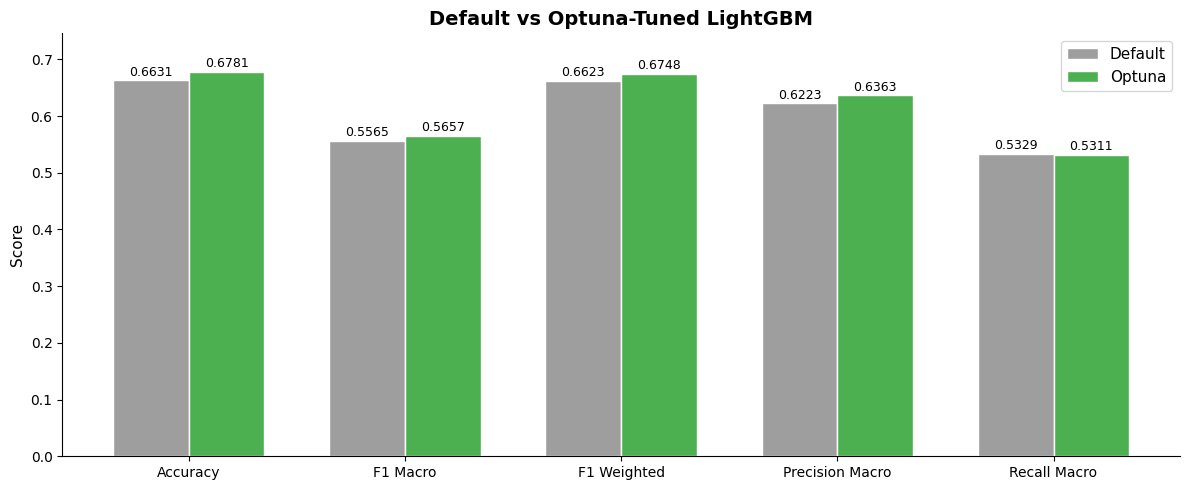

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics_default = result_default["metrics"]
metrics_optuna = result_best["metrics"]

# Select the metrics you care about (adjust if your compute_metrics returns different keys)
plot_metrics = ["accuracy", "f1_macro", "f1_weighted", "precision_macro", "recall_macro"]
plot_metrics = [m for m in plot_metrics if m in metrics_default]

default_vals = [metrics_default[m] for m in plot_metrics]
optuna_vals = [metrics_optuna[m] for m in plot_metrics]

x = np.arange(len(plot_metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width / 2, default_vals, width, label="Default", color="#9e9e9e", edgecolor="white")
bars2 = ax.bar(x + width / 2, optuna_vals, width, label="Optuna", color="#4caf50", edgecolor="white")

# Value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.003, f"{h:.4f}",
                ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Score", fontsize=11)
ax.set_title("Default vs Optuna-Tuned LightGBM", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([m.replace("_", " ").title() for m in plot_metrics], fontsize=10)
ax.set_ylim(0, max(max(default_vals), max(optuna_vals)) * 1.1)
ax.legend(fontsize=11)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

### 3.2 Confusion Matrices

Side-by-side confusion matrices for both models. Differences in misclassification patterns reveal which classes benefited most from hyperparameter tuning.

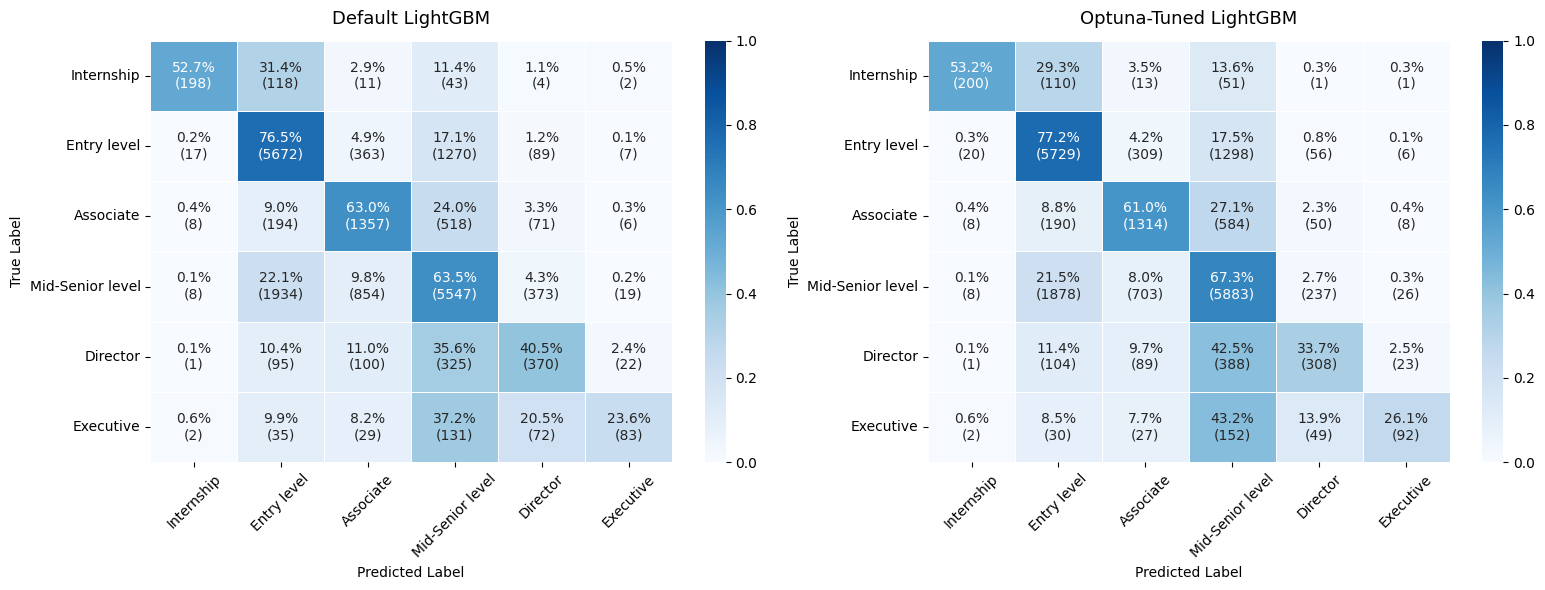

In [39]:
from sklearn.metrics import confusion_matrix

EXPERIENCE_LABELS = {
    0: "Internship",
    1: "Entry level",
    2: "Associate",
    3: "Mid-Senior level",
    4: "Director",
    5: "Executive",
}

model_default = result_default["model"]
model_optuna = result_best["model"]

y_pred_default = model_default.predict(X_test)
y_pred_optuna = model_optuna.predict(X_test)

labels = sorted(y_test.unique())
target_names = [EXPERIENCE_LABELS.get(l, str(l)) for l in labels]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_pred, title in zip(
    axes,
    [y_pred_default, y_pred_optuna],
    ["Default LightGBM", "Optuna-Tuned LightGBM"],
):
    cm_raw = confusion_matrix(y_test, y_pred, labels=labels)

    # Row-normalize (recall per class)
    row_sums = cm_raw.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums == 0, 1, row_sums)
    cm_norm = cm_raw.astype(float) / row_sums

    # Annotation: percentage on top, raw count below
    annot = np.empty_like(cm_raw, dtype=object)
    for i in range(cm_raw.shape[0]):
        for j in range(cm_raw.shape[1]):
            annot[i, j] = f"{cm_norm[i, j]:.1%}\n({cm_raw[i, j]})"

    sns.heatmap(
        cm_norm,
        annot=annot,
        fmt="",
        cmap="Blues",
        xticklabels=target_names,
        yticklabels=target_names,
        ax=ax,
        vmin=0,
        vmax=1,
        linewidths=0.5,
        linecolor="white",
    )
    ax.set_title(title, fontsize=13, pad=12)
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

## 4. Summary

Optuna hyperparameter tuning was applied to the LightGBM model, but the improvements were marginal. Accuracy went from 66.31% to 67.81%, F1 Weighted from 66.23% to 67.48%, and Precision Macro from 62.23% to 63.63%. F1 Macro saw only a ~1% bump, and Recall Macro actually dropped slightly (53.29% to 53.11%).

The confusion matrices tell a similar story. Both models follow the same pattern: they perform best on the majority classes (Mid-Senior level and Entry level) and struggle with underrepresented classes like Internship, Director, and Executive. The Optuna-tuned version shifts some predictions slightly (e.g., Mid-Senior level recall improves from 63.5% to 67.3%), but the overall misclassification patterns remain nearly identical.

In short, Optuna did find a marginally better configuration, but the gains are too small to meaningfully change the model's behavior or address its core weakness: poor performance on minority seniority levels.